# Evaluating Splice Usage Predictions by Trajectory Type

For each species/tissue, developmental splice-site trajectories have been clustered by
**shape** and annotated with a `ClusterShape` label (see
[splice_trajectory_clustering.ipynb](splice_trajectory_clustering.ipynb)):
`up_early`, `up_late`, `down_early`, `flat_high`, `up-down`, ... .

This notebook joins those annotated clusters to **model predictions** and asks:

> *How well does the model recover each type of developmental trajectory?*

## Pipeline
1. **Load usage predictions** — per (site, condition) true & predicted SSE from `usage_{species}.npz`.
2. **Trajectory correlations** — Pearson r / MAE / cosine per site × tissue
   (same definition as the *Calculate trajectory correlations* section of `splice_model_eval.ipynb`).
3. **Attach cluster annotations** — join each site × tissue to its `ClusterShape`.
4. **Evaluate by trajectory type** —
   metric distributions, mean true-vs-predicted profile, and example sites per cluster shape.

## Setup

In [20]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

try:
    from alphagenome_pytorch.plotting.splicing import (
        TISSUE_COLORS, TISSUE_ORDER, SPECIES_SCI,
    )
except Exception:  # keep the notebook usable even without the package
    SPECIES_SCI = {"human": "Homo_sapiens", "mouse": "Mus_musculus",
                   "rat": "Rattus_norvegicus", "rabbit": "Oryctolagus_cuniculus",
                   "opossum": "Monodelphis_domestica"}
    TISSUE_ORDER = ["Brain", "Midbrain", "Cerebellum", "Heart", "Kidney",
                    "Liver", "Ovary", "Testis"]
    TISSUE_COLORS = {}

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})
sns.set_style("whitegrid")

In [22]:
# ── Paths / config ────────────────────────────────────────────────────────────
SPECIES   = "human"

# Model predictions (usage_{species}.npz with chr_pos / cond_ids / true / pred)
PRED_ROOT = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_encode_intersect_usage_pc_traj_human_mouse_rat_rabbit_opossum/preds_intersect_protein_coding"
USAGE_NPZ = os.path.join(PRED_ROOT, SPECIES, f"usage_{SPECIES}.npz")

# Condition metadata: condition index -> "Tissue_Timepoint"
ANN_DATA_DIR  = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data"
METADATA_JSON = os.path.join(ANN_DATA_DIR, SPECIES_SCI[SPECIES], "usage.json")

# Annotated trajectory clusters (one row per site x Tissue -> Cluster / ClusterShape).
# The all-tissues clustering is the natural join partner because predictions are
# also per site x tissue x timepoint. Point this at a per-tissue metadata parquet
# (e.g. clustering_usage_human_Brain/human_brain_test_clustering_metadata.parquet)
# to explore a single tissue's clustering instead.
CLUST_DIR = "/home/elek/sds/sd17d003/Anamaria/gp_usage/"
TISSUE = "Brain"
CLUSTER_PARQUET = os.path.join(CLUST_DIR, f"clustering_usage_{SPECIES}_{TISSUE}", f"{SPECIES}_{TISSUE.lower()}_test_clustering_metadata.parquet")

# Where to write figures / summary tables
OUT_DIR = os.path.join(PRED_ROOT, SPECIES, "trajectory_types")
os.makedirs(OUT_DIR, exist_ok=True)

for p in (USAGE_NPZ, METADATA_JSON, CLUSTER_PARQUET):
    print(("OK  " if os.path.exists(p) else "MISS") + f"  {p}")

OK    /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_encode_intersect_usage_pc_traj_human_mouse_rat_rabbit_opossum/preds_intersect_protein_coding/human/usage_human.npz
OK    /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/usage.json
OK    /home/elek/sds/sd17d003/Anamaria/gp_usage/clustering_usage_human_Brain/human_brain_test_clustering_metadata.parquet


In [23]:
# Shape taxonomy is shared via alphagenome_pytorch.plotting.splicing
# (same source of truth as scripts/cluster_trajectories.py and
# splice_trajectory_clustering.ipynb).
from alphagenome_pytorch.plotting.splicing import SHAPE_COLORS, SHAPE_ORDER

shape_color = lambda s: SHAPE_COLORS.get(s, "#7f7f7f")

## 1 — Load usage predictions

Load per-(site, condition) true and predicted SSE and split each condition into its
`Tissue` and `Timepoint`.

In [24]:
with open(METADATA_JSON) as f:
    metadata = json.load(f)
idx_to_label = {int(v): k for k, v in metadata.get("condition_labels", {}).items()}

data = np.load(USAGE_NPZ)
chr_pos  = np.asarray(data["chr_pos"]).astype(str)
cond_ids = np.asarray(data["cond_ids"], dtype=int)
trues    = np.asarray(data["true"], dtype=float)
preds    = np.asarray(data["pred"], dtype=float)

tissues    = np.array([idx_to_label[c].rsplit("_", 1)[0] for c in cond_ids])
timepoints = np.array([int(idx_to_label[c].rsplit("_", 1)[1]) for c in cond_ids])

usage_df = pd.DataFrame({
    "chr_pos":    chr_pos,
    "cond_idx":   cond_ids,
    "tissue":     tissues,
    "timepoint":  timepoints,
    "true_usage": trues,
    "pred_usage": preds,
})
usage_df[["chromosome", "position"]] = usage_df["chr_pos"].str.split(":", expand=True)
usage_df["position"] = usage_df["position"].astype(int)

print(f"{len(usage_df):,} observations  |  "
      f"{usage_df['chr_pos'].nunique():,} sites  |  "
      f"{usage_df['tissue'].nunique()} tissues  |  "
      f"{usage_df['timepoint'].nunique()} timepoints")
usage_df.head()

Exception ignored in: <function NpzFile.__del__ at 0x7f8da3f76a20>
Traceback (most recent call last):
  File "/home/elek/miniforge3/envs/alphagenome_pytorch_genomicsxai/lib/python3.12/site-packages/numpy/lib/_npyio_impl.py", line 230, in __del__
    self.close()
  File "/home/elek/miniforge3/envs/alphagenome_pytorch_genomicsxai/lib/python3.12/site-packages/numpy/lib/_npyio_impl.py", line 225, in close
    self.fid.close()
OSError: [Errno 5] Input/output error


1,305,511 observations  |  19,899 sites  |  8 tissues  |  15 timepoints


,chr_pos,cond_idx,tissue,timepoint,true_usage,pred_usage,chromosome,position
0,1:1535506,0,Brain,1,0.796,0.636684,1,1535506
1,1:1535588,0,Brain,1,0.864,0.619059,1,1535588
2,1:1535796,0,Brain,1,0.714,0.397107,1,1535796
3,1:1539683,0,Brain,1,0.578,0.543266,1,1539683
4,1:1539789,0,Brain,1,0.353,0.548752,1,1539789


## 2 — Trajectory correlations per site × tissue

For every site × tissue we treat the SSE values across timepoints as a trajectory and
score how closely the predicted trajectory matches the true one (Pearson r, MAE, cosine).
This reuses the metric definitions from the *Calculate trajectory correlations* section of
`splice_model_eval.ipynb`.

In [25]:
def _pearson_safe(x, y):
    if len(x) < 2 or np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def _mean_safe(a):
    a = np.asarray(a, float)
    a = a[np.isfinite(a)]
    return np.mean(a) if len(a) else np.nan

def _traj_metrics(g):
    x = g["true_usage"].to_numpy(float)
    y = g["pred_usage"].to_numpy(float)
    nx, ny = np.linalg.norm(x), np.linalg.norm(y)
    obs = x > 0
    return pd.Series({
        "pearson_r":       _pearson_safe(x, y),
        "mae":             np.sqrt(np.mean((x - y) ** 2)),
        "cosine":          float(np.dot(x, y) / (nx * ny)) if nx > 0 and ny > 0 else np.nan,
        "n_obs_usage":     int(g.loc[obs, "cond_idx"].nunique()),
        "mean_true_usage": _mean_safe(x),
        "mean_pred_usage": _mean_safe(y),
        "max_true_usage":  float(x.max()) if len(x) else np.nan,
        "min_obs_usage":   float(x[obs].min()) if obs.any() else np.nan,
    })

site_corr = (
    usage_df.groupby(["chr_pos", "chromosome", "position", "tissue"], as_index=False)
    .apply(_traj_metrics)
    .reset_index(drop=True)
)

# Drop sites never observed as used (all true == 0) -> undefined trajectory
n_no_obs = site_corr["min_obs_usage"].isna().sum()
print(f"Sites with no observed usage > 0: {n_no_obs:,} / {len(site_corr):,} "
      f"({n_no_obs / len(site_corr):.1%}) — removed")
site_corr = site_corr[site_corr["min_obs_usage"].notna()].reset_index(drop=True)
print(f"{len(site_corr):,} site x tissue trajectories scored")
site_corr.head()

Sites with no observed usage > 0: 26,778 / 159,192 (16.8%) — removed
132,414 site x tissue trajectories scored


,chr_pos,chromosome,position,tissue,pearson_r,mae,cosine,n_obs_usage,mean_true_usage,mean_pred_usage,max_true_usage,min_obs_usage
0,10:100969590,10,100969590,Brain,-0.139942,0.163634,0.994693,6.0,0.941667,0.806140,1.000,0.821
1,10:100969590,10,100969590,Cerebellum,0.612007,0.339777,0.997161,4.0,0.979250,0.642605,1.000,0.958
2,10:100969590,10,100969590,Heart,NaN,0.247475,1.000000,1.0,0.962000,0.714525,0.962,0.962
3,10:100969590,10,100969590,Kidney,-1.000000,0.296791,0.986685,2.0,0.950000,0.681177,1.000,0.900
4,10:100969590,10,100969590,Liver,0.351000,0.184691,0.993761,5.0,0.887800,0.726527,0.947,0.727


## 3 — Attach cluster annotations

Join each scored site × tissue trajectory to its annotated `ClusterShape`.

In [26]:
clusters = pd.read_parquet(CLUSTER_PARQUET)
clusters["chromosome"] = clusters["Chromosome"].astype(str)
clusters["position"]   = clusters["Position"].astype(int)

# The all-tissues clustering carries a Tissue column; per-tissue metadata files do not.
if "Tissue" in clusters.columns:
    clusters["tissue"] = clusters["Tissue"].astype(str)
    join_keys = ["chromosome", "position", "tissue"]
else:
    # Per-tissue clustering file: the clusters were derived from TISSUE alone, so the
    # labels only describe that tissue's developmental trajectories. Restrict to it.
    # Joining on site alone would give every tissue of a site the same label, and a
    # cluster's pattern would be averaged away against tissues where those sites are
    # flat or unexpressed (they also drag in all-zero trajectories).
    join_keys = ["chromosome", "position"]
    n_before  = len(site_corr)
    usage_df  = usage_df[usage_df["tissue"] == TISSUE].reset_index(drop=True)
    site_corr = site_corr[site_corr["tissue"] == TISSUE].reset_index(drop=True)
    print(f"No Tissue column in clustering file — clusters are {TISSUE}-derived, so "
          f"trajectories are restricted to {TISSUE}: {len(site_corr):,} / {n_before:,}")

keep = join_keys + ["Cluster", "ClusterShape", "ClusterMeanSSE", "ClusterRangeSSE"]
traj = site_corr.merge(clusters[keep].drop_duplicates(join_keys),
                       on=join_keys, how="inner")

print(f"Matched {len(traj):,} / {len(site_corr):,} scored trajectories to a cluster "
      f"({len(traj) / len(site_corr):.1%})")
print(f"Tissues in scope: {sorted(traj['tissue'].unique())}")
print(f"Cluster shapes present: {sorted(traj['ClusterShape'].dropna().unique())}")
traj.head()

No Tissue column in clustering file — clusters are Brain-derived, so trajectories are restricted to Brain: 17,852 / 132,414
Matched 15,518 / 17,852 scored trajectories to a cluster (86.9%)
Tissues in scope: ['Brain']
Cluster shapes present: ['complex', 'down-up', 'down_late', 'down_mid', 'flat_high', 'flat_low', 'flat_mid', 'flat_mid_high', 'flat_mid_low', 'up_early', 'up_late', 'up_mid']


,chr_pos,chromosome,position,tissue,pearson_r,mae,cosine,n_obs_usage,mean_true_usage,mean_pred_usage,max_true_usage,min_obs_usage,Cluster,ClusterShape,ClusterMeanSSE,ClusterRangeSSE
0,10:100969590,10,100969590,Brain,-0.139942,0.163634,0.994693,6.0,0.941667,0.806140,1.000,0.821,37,flat_high,0.965402,0.017017
1,10:100969923,10,100969923,Brain,0.381688,0.221741,0.896971,8.0,0.306625,0.149333,0.643,0.074,8,down_mid,0.264190,0.238742
2,10:100972528,10,100972528,Brain,0.769017,0.503524,0.964488,9.0,0.583111,0.134042,1.000,0.100,23,up_early,0.582615,0.433049
3,10:100972893,10,100972893,Brain,-0.626373,0.492049,0.789550,7.0,0.042875,0.521168,0.091,0.028,1,flat_low,0.058610,0.007229
4,10:100973035,10,100973035,Brain,-0.061282,0.331932,0.983036,11.0,0.982909,0.677396,1.000,0.886,37,flat_high,0.965402,0.017017


## 4 — Evaluate by trajectory type

### 4.1 How many trajectories of each type?

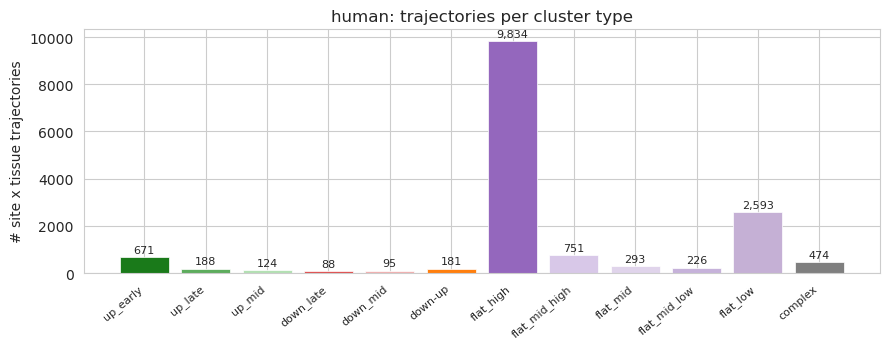

In [27]:
present = [s for s in SHAPE_ORDER if s in set(traj["ClusterShape"])]
counts  = traj["ClusterShape"].value_counts().reindex(present).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(max(7, len(present) * 0.75), 3.6))
bars = ax.bar(range(len(present)), counts.values,
              color=[shape_color(s) for s in present], edgecolor="white", lw=0.5)
for b, c in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + max(counts.values) * 0.01,
            f"{c:,}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(present)))
ax.set_xticklabels(present, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("# site x tissue trajectories")
ax.set_title(f"{SPECIES}: trajectories per cluster type")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "counts_by_trajectory_type.png"), dpi=200, bbox_inches="tight")
plt.show()

### 4.2 Prediction accuracy per trajectory type

Distribution of the trajectory metrics within each cluster shape. This shows which
developmental patterns the model captures well and which it struggles with. Only
trajectories with more than a few observed timepoints are informative for Pearson r,
so we require `n_obs_usage > 3`.

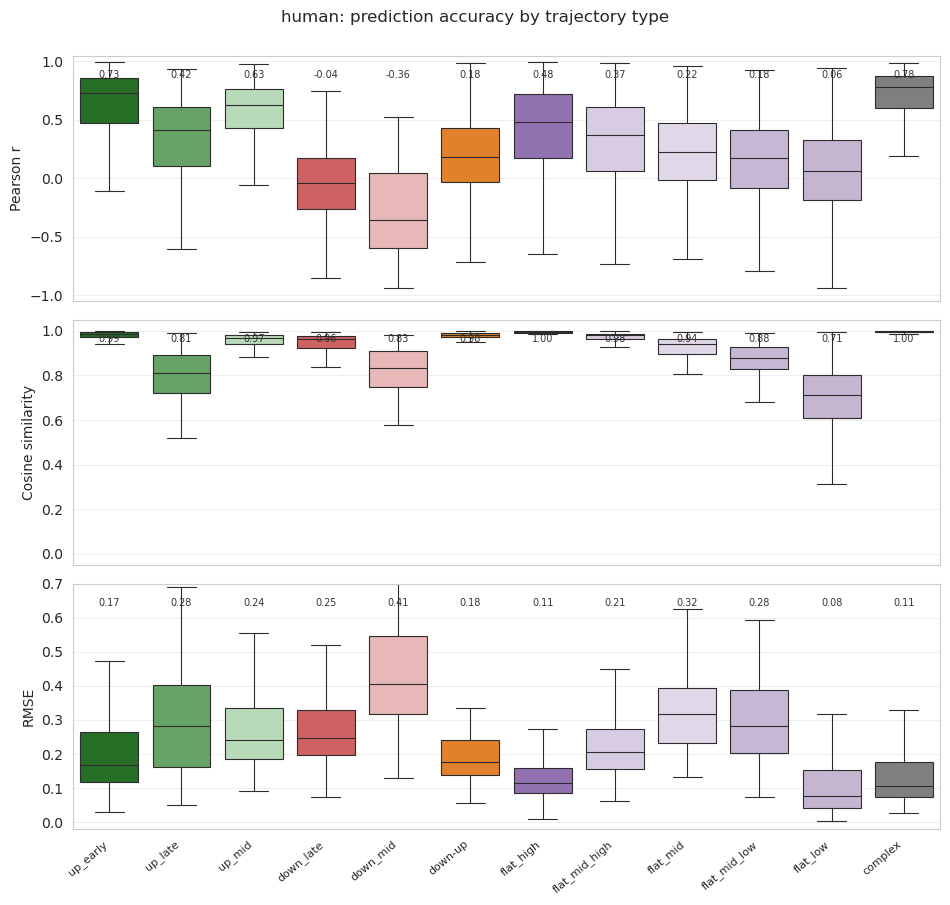

In [28]:
plot_df = traj[traj["n_obs_usage"] > 3].copy()
plot_df["ClusterShape"] = pd.Categorical(plot_df["ClusterShape"], categories=present, ordered=True)

metric_specs = [
    ("pearson_r", "Pearson r", (-1.05, 1.05)),
    ("cosine",    "Cosine similarity", (-0.05, 1.05)),
    ("mae",       "RMSE",       (-0.02, 0.7)),
]
fig, axes = plt.subplots(len(metric_specs), 1,
                         figsize=(max(8, len(present) * 0.8), 3.0 * len(metric_specs)),
                         sharex=True)
pal = {s: shape_color(s) for s in present}
for ax, (key, label, ylim) in zip(axes, metric_specs):
    sns.boxplot(data=plot_df, x="ClusterShape", y=key, order=present,
                palette=pal, showfliers=False, ax=ax, linewidth=0.8)
    med = plot_df.groupby("ClusterShape", observed=True)[key].median().reindex(present)
    for i, m in enumerate(med.values):
        if np.isfinite(m):
            ax.text(i, ylim[1] - 0.06 * (ylim[1] - ylim[0]), f"{m:.2f}",
                    ha="center", va="top", fontsize=7, color="#333")
    ax.set_ylim(*ylim)
    ax.set_ylabel(label)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)
axes[-1].set_xticklabels(present, rotation=40, ha="right", fontsize=8)
fig.suptitle(f"{SPECIES}: prediction accuracy by trajectory type", y=1.0)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "metrics_by_trajectory_type.png"), dpi=200, bbox_inches="tight")
plt.show()

### 4.3 True vs predicted profile per cluster

Rendered with the shared `plot_cluster_trajectory_profiles` helper — the same style as
the cluster profiles saved by [scripts/cluster_trajectories.py](../../scripts/cluster_trajectories.py)
and [splice_trajectory_clustering.ipynb](splice_trajectory_clustering.ipynb): thin
individual trajectories + a mean ± SD band + a bold **plain-mean** line, one panel per
cluster, coloured by shape. **True** is solid, **predicted** dashed.

To match the clustering plots, each trajectory is GP-smoothed **individually first** using
the very same `smooth_all_trajectories` / `_smooth_one` as the clustering pipeline, and the
bold line is the plain average of those smooth curves. Smoothing the *average* instead
over-smooths, and a plain average of the *raw* trajectories is far too rough — the
smoothing has to be per-trajectory.

`optimize=False` holds the length-scale fixed (fast, and closely matches the script's
roughness); pass `optimize=True` to fit hyper-parameters per trajectory exactly like the
script, at a large speed cost.

GP: 100%|██████████| 15518/15518 [00:32<00:00, 472.36site/s]


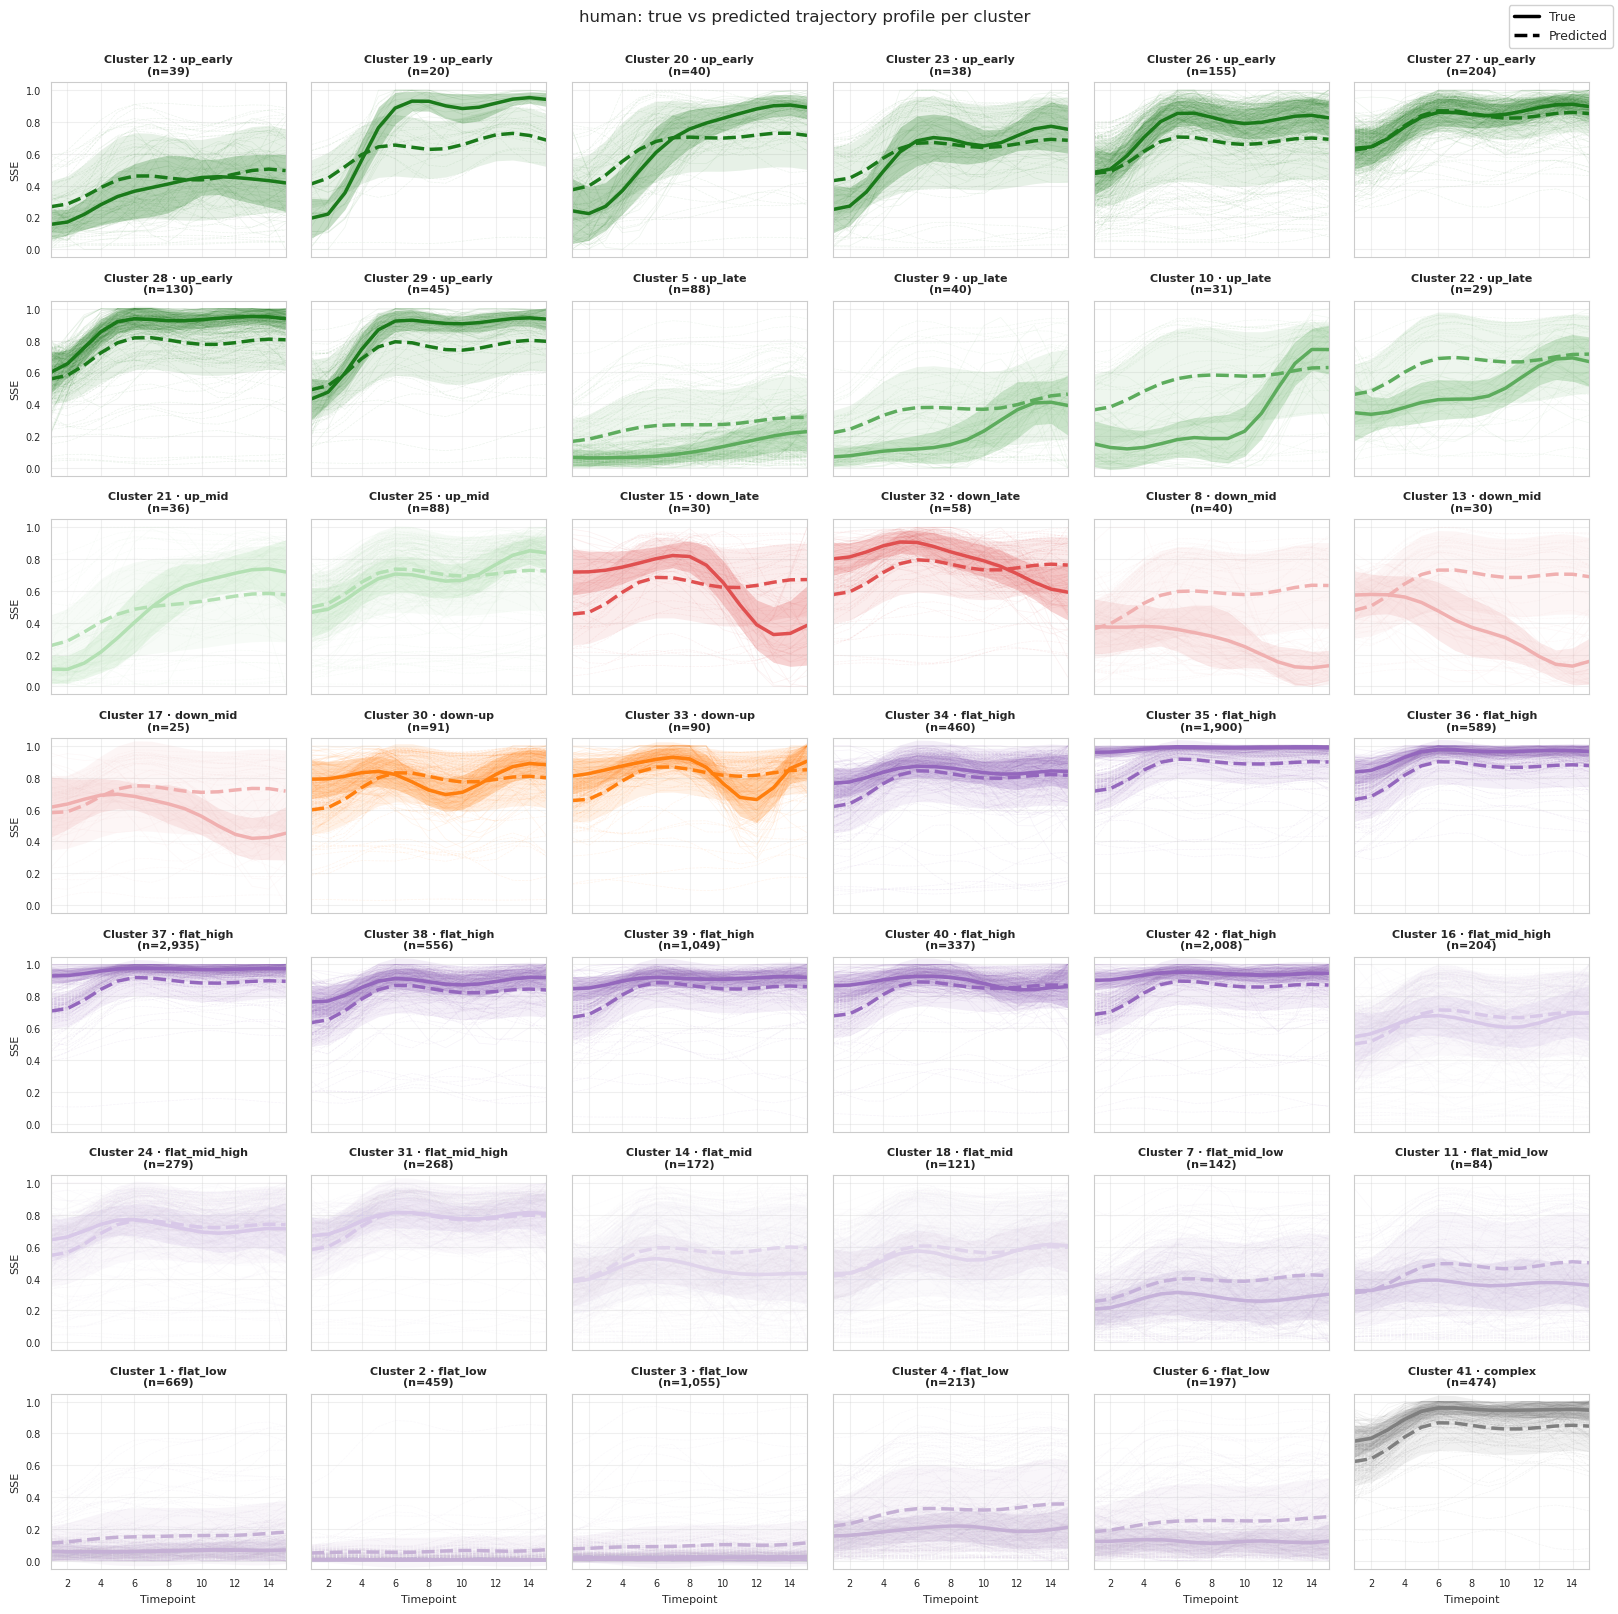

In [29]:
from alphagenome_pytorch.plotting.splicing import (
    smooth_all_trajectories, plot_cluster_trajectory_profiles,
)

traj_obs = usage_df.merge(
    traj[join_keys + ["Cluster", "ClusterShape"]].drop_duplicates(join_keys),
    on=join_keys, how="inner",
)
traj_obs = traj_obs[traj_obs["ClusterShape"].isin(present)]

# ── Wide (trajectory x timepoint) matrices for true and predicted usage ────────
# A trajectory is one site x tissue; averaging collapses any replicate observations.
TP_GRID = np.array(sorted(traj_obs["timepoint"].unique()), dtype=float)
true_wide = (traj_obs.pivot_table(index=["chr_pos", "tissue"], columns="timepoint",
                                  values="true_usage", aggfunc="mean")
                     .reindex(columns=TP_GRID))
pred_wide = (traj_obs.pivot_table(index=["chr_pos", "tissue"], columns="timepoint",
                                  values="pred_usage", aggfunc="mean")
                     .reindex(columns=TP_GRID))
traj_cluster = (traj_obs.drop_duplicates(["chr_pos", "tissue"])
                        .set_index(["chr_pos", "tissue"])["Cluster"]
                        .reindex(true_wide.index).to_numpy())

# GP-smooth each trajectory individually before averaging, with the same smoother the
# clustering pipeline uses (smooth_all_trajectories -> _smooth_one). It takes read counts
# to decide which timepoints are observed; here a timepoint is observed wherever usage is
# non-NaN. optimize=False fixes the length-scale (fast, ~matches the script's roughness);
# optimize=True fits hyper-parameters per trajectory exactly like the script, but is slow.
Tv, *_ = smooth_all_trajectories(true_wide, true_wide.notna().astype(int), TP_GRID,
                                 optimize=False, n_jobs=-1)
Pv, *_ = smooth_all_trajectories(pred_wide, pred_wide.notna().astype(int), TP_GRID,
                                 optimize=False, n_jobs=-1)

# Order clusters by shape then id, colour by shape, label panels with the shape
cluster_shape = (traj.dropna(subset=["Cluster"])
                     .drop_duplicates("Cluster")
                     .set_index("Cluster")["ClusterShape"].to_dict())
shape_rank = {s: i for i, s in enumerate(SHAPE_ORDER)}
cluster_order = sorted(
    pd.unique(traj_cluster[~pd.isna(traj_cluster)]),
    key=lambda k: (shape_rank.get(cluster_shape.get(k), len(SHAPE_ORDER)), k),
)
color_by = {k: shape_color(cluster_shape.get(k)) for k in cluster_order}
title_by = {k: cluster_shape.get(k) for k in cluster_order}

fig = plot_cluster_trajectory_profiles(
    grid=TP_GRID, features=Tv, labels=traj_cluster,
    features2=Pv, series_labels=("True", "Predicted"),
    cluster_order=cluster_order, color_by=color_by, title_by=title_by,
    n_cols=6, n_draw=120,
    ylabel="SSE", xlabel="Timepoint",
    suptitle=f"{SPECIES}: true vs predicted trajectory profile per cluster",
)
fig.savefig(os.path.join(OUT_DIR, "true_vs_pred_profile_by_cluster.png"),
            dpi=200, bbox_inches="tight")
plt.show()

### 4.4 Example sites per trajectory type

Individual trajectories give a feel for the spread behind the averages. For a chosen
cluster shape we plot the true (solid) and predicted (dashed) SSE of a few example sites,
picking the best-correlated ones so the intended pattern is clearly visible.

In [30]:
def plot_examples(shape, n=6, rank_by="pearson_r", ascending=False,
                  min_obs=6, random=False, seed=0):
    """Plot true (solid) vs predicted (dashed) trajectories for example sites of a shape."""
    cand = traj[(traj["ClusterShape"] == shape) & (traj["n_obs_usage"] >= min_obs)].copy()
    if cand.empty:
        print(f"No sites with n_obs_usage >= {min_obs} for shape '{shape}'")
        return
    if random:
        cand = cand.sample(min(n, len(cand)), random_state=seed)
    else:
        cand = cand.sort_values(rank_by, ascending=ascending).head(n)

    color  = shape_color(shape)
    n_cols = min(3, len(cand))
    n_rows = (len(cand) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.6, n_rows * 2.8),
                             squeeze=False, sharey=True)
    for ax_i, (_, row) in enumerate(cand.iterrows()):
        ax  = axes[ax_i // n_cols, ax_i % n_cols]
        sub = usage_df[(usage_df["chr_pos"] == row["chr_pos"]) &
                       (usage_df["tissue"] == row["tissue"])].sort_values("timepoint")
        ax.plot(sub["timepoint"], sub["true_usage"], "-o", color=color, ms=4, lw=1.6, label="True")
        ax.plot(sub["timepoint"], sub["pred_usage"], "--x", color=color, ms=5, lw=1.6, label="Predicted")
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f"{row['tissue']} {row['chr_pos']}\n"
                     f"r={row['pearson_r']:.2f}  RMSE={row['mae']:.2f}", fontsize=8)
        ax.grid(alpha=0.3)
        if ax_i % n_cols == 0:
            ax.set_ylabel("SSE")
        if ax_i // n_cols == n_rows - 1:
            ax.set_xlabel("Timepoint")
    for j in range(len(cand), n_rows * n_cols):
        axes[j // n_cols, j % n_cols].set_visible(False)
    fig.suptitle(f"{SPECIES} — '{shape}' examples", y=1.0, fontsize=11, fontweight="bold")
    plt.tight_layout()
    return fig

No sites with n_obs_usage >= 6 for shape 'down_early'
No sites with n_obs_usage >= 6 for shape 'up-down'


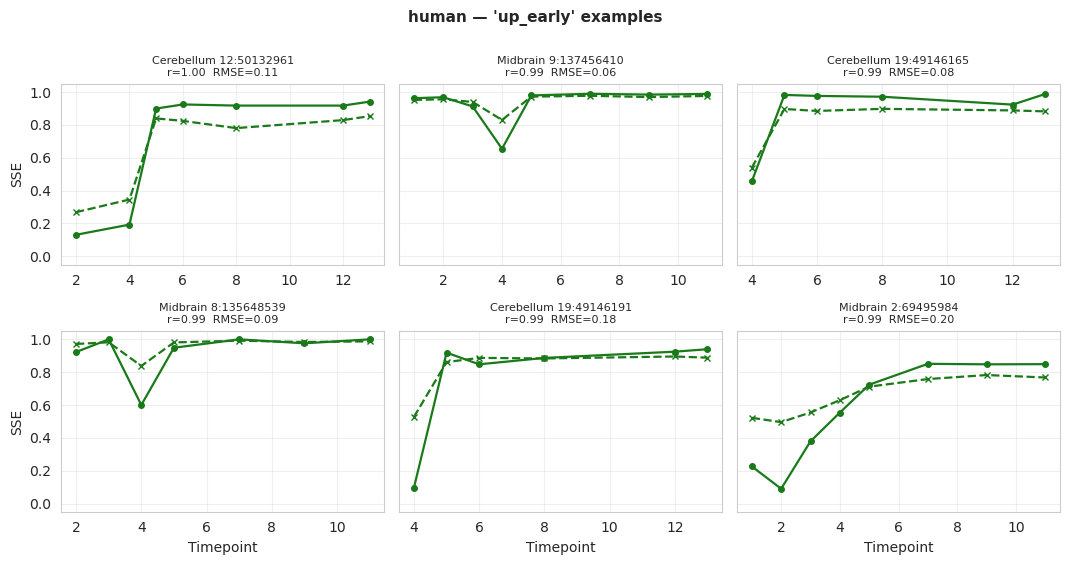

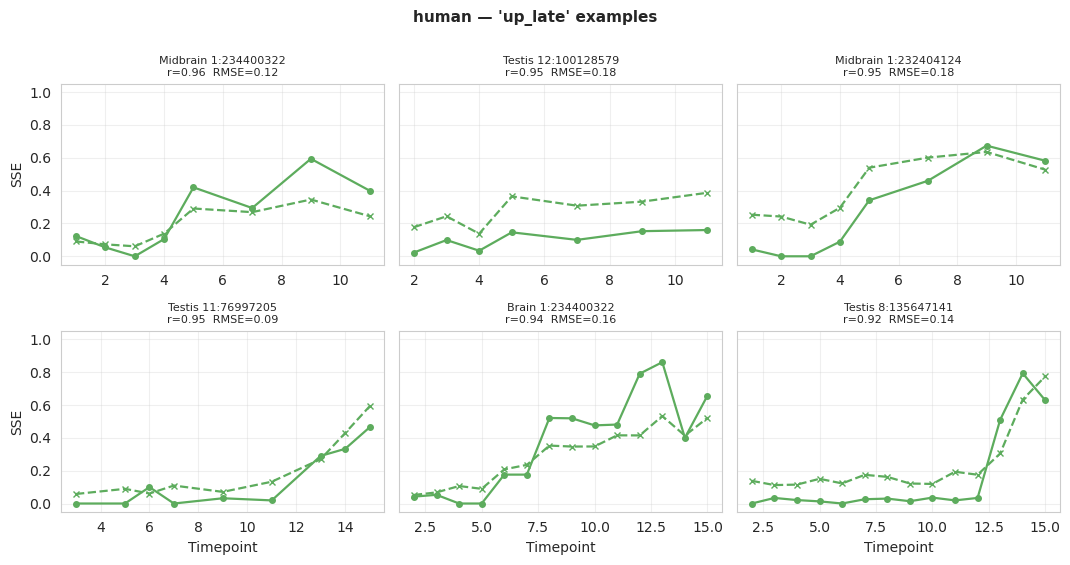

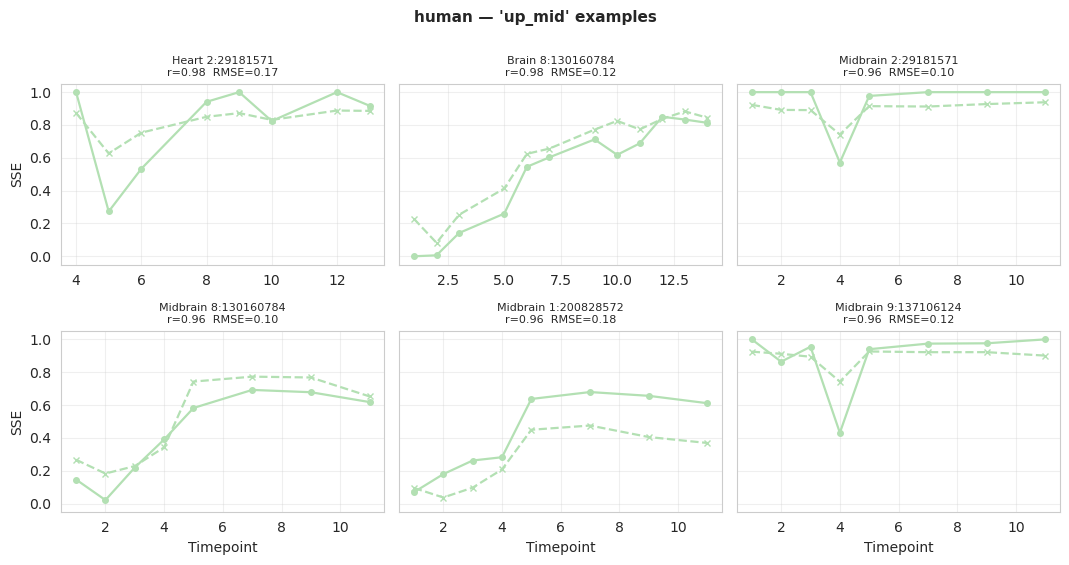

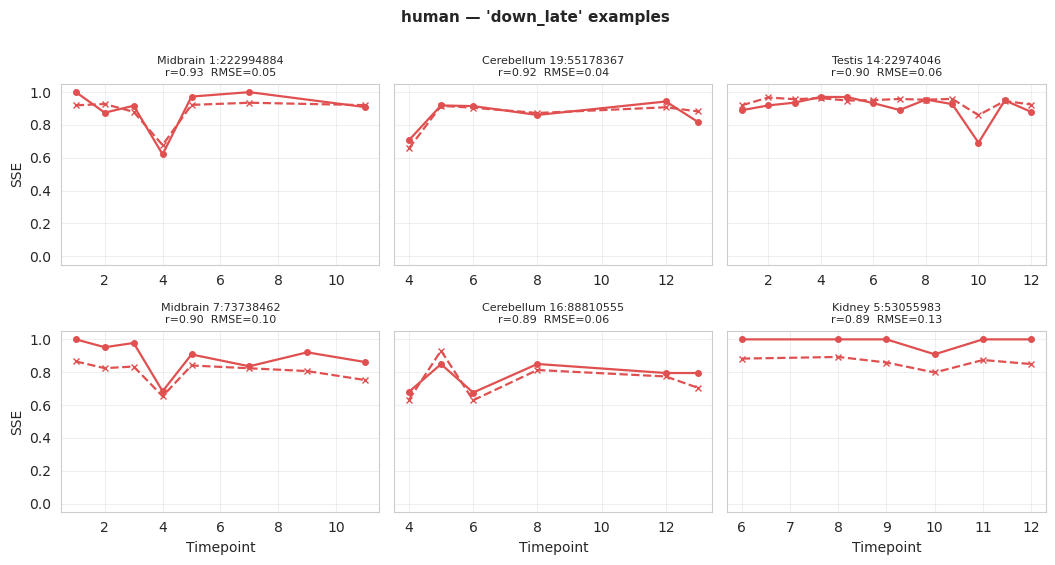

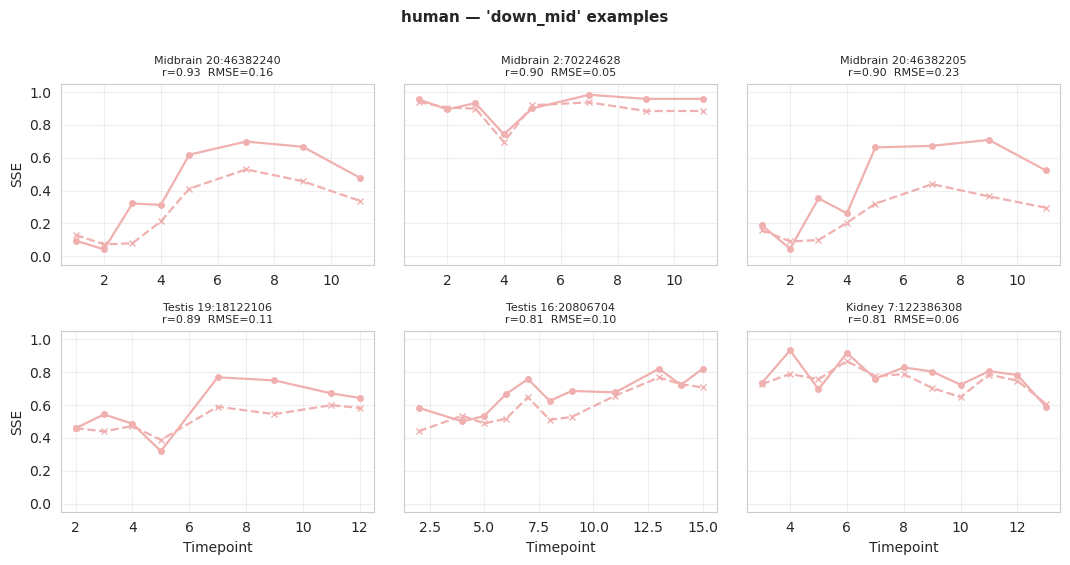

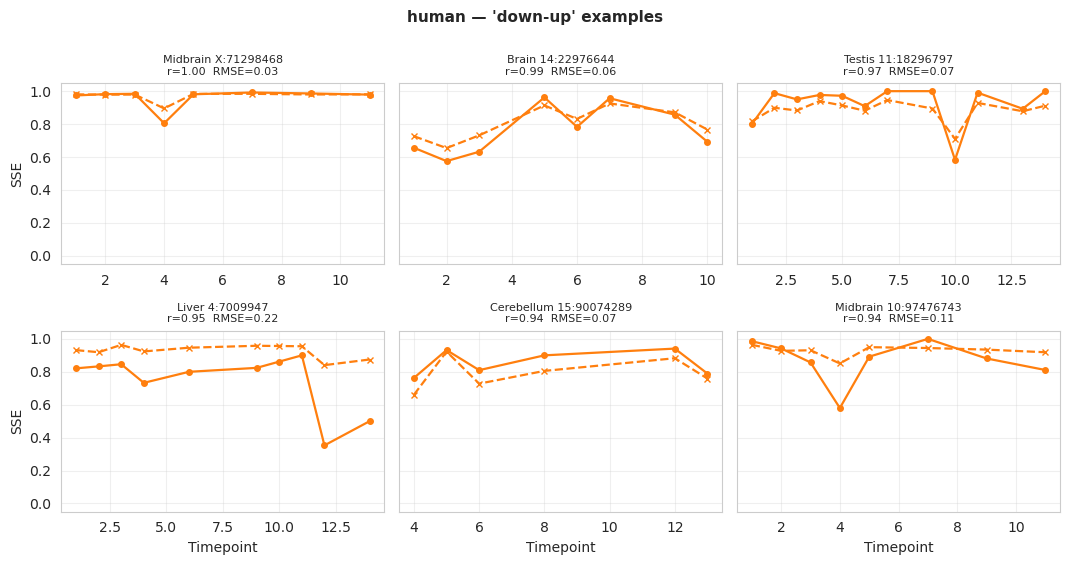

In [16]:
# Example: the best correlated sites of a given trajectory shape (except flat/complex)
plot_shapes = [s for s in SHAPE_ORDER if s not in ("flat_high", "flat_mid_high", "flat_mid", "flat_mid_low", "flat_low", "complex")]
for shape in plot_shapes:
    plot_examples(shape, n=6)

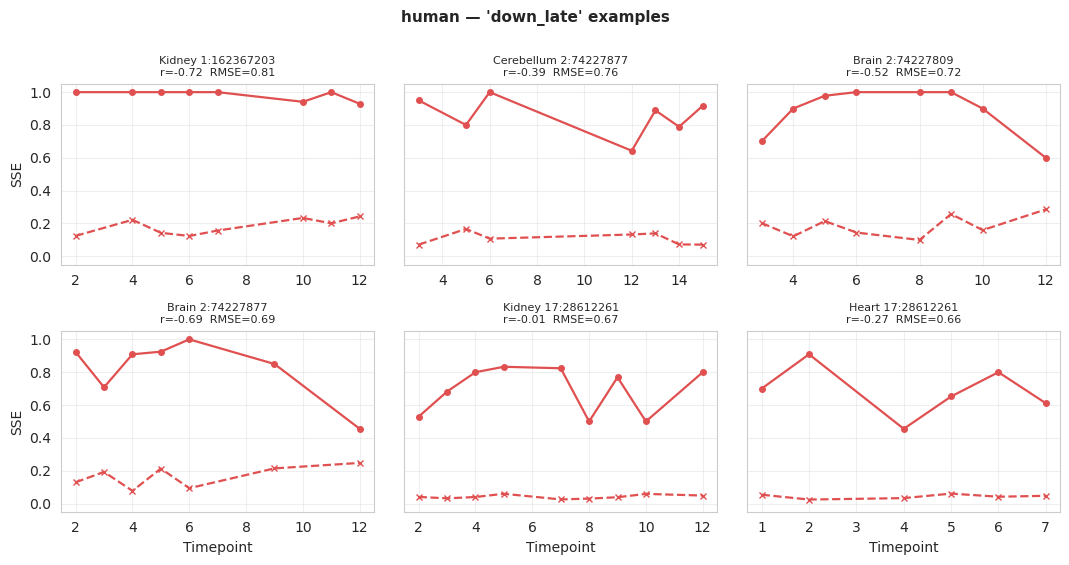

In [13]:
# Example: the worst-recovered sites of a shape (largest RMSE) — where the model fails
plot_examples("down_late", n=6, rank_by="mae", ascending=False)
plt.show()

### 4.5 Summary table

Median metrics per trajectory type, saved alongside the figures.

In [31]:
summary = (
    traj[traj["n_obs_usage"] > 3]
    .groupby("ClusterShape")
    .agg(n_trajectories=("chr_pos", "size"),
         median_pearson_r=("pearson_r", "median"),
         mean_pearson_r=("pearson_r", "mean"),
         median_cosine=("cosine", "median"),
         median_rmse=("mae", "median"),
         mean_true_usage=("mean_true_usage", "mean"),
         mean_n_obs=("n_obs_usage", "mean"))
    .reindex(present)
    .round(3)
)
out_csv = os.path.join(OUT_DIR, "trajectory_type_metrics_summary.csv")
summary.to_csv(out_csv)
print(f"Saved -> {out_csv}")
summary

Saved -> /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_encode_intersect_usage_pc_traj_human_mouse_rat_rabbit_opossum/preds_intersect_protein_coding/human/trajectory_types/trajectory_type_metrics_summary.csv


,n_trajectories,median_pearson_r,mean_pearson_r,median_cosine,median_rmse,mean_true_usage,mean_n_obs
ClusterShape,,,,,,,
up_early,671,0.727,0.639,0.986,0.168,0.761,10.526
up_late,183,0.415,0.354,0.809,0.282,0.236,10.000
up_mid,124,0.631,0.555,0.969,0.241,0.618,10.847
down_late,88,-0.044,-0.047,0.964,0.246,0.746,9.852
down_mid,94,-0.359,-0.276,0.832,0.406,0.383,10.979
down-up,181,0.184,0.188,0.982,0.176,0.819,10.508
flat_high,9834,0.478,0.428,0.996,0.114,0.939,11.731
flat_mid_high,751,0.367,0.325,0.979,0.207,0.710,10.780
flat_mid,293,0.223,0.211,0.940,0.318,0.488,10.679
